## Does proportion contribute to ranking?

**Goal:** Test whether `proportion` the fraction of cells within a perturbation that display the target phenotype influence gene rank.

- A strong negative Spearman ρ (higher proportion → lower/better rank) would indicate that phenotypic penetrance is a meaningful driver of prioritisation.
- A flat or near-zero relationship would suggest that rank is determined by the distance scores alone and `proportion` is a corroborating descriptor without independent predictive power.


In [1]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(viridisLite)
    library(stringr)
    library(stats)
    library(grid)
    library(gridExtra)
})

options(warn = -1)

In [2]:
truncate_palette <- function(palette_fun, min_val = 0.15, max_val = 1.0, n = 256) {
  vals <- seq(min_val, max_val, length.out = n)
  palette_fun(n)[pmax(1, pmin(n, round(vals * n)))]
}

sig_stars <- function(p) {
  if (is.na(p)) return('n.s.')
  if (p < 0.001) return('***')
  if (p < 0.01) return('**')
  if (p < 0.05) return('*')
  'n.s.'
}

In [3]:
# setting result dir
results_dir <- normalizePath('../results/moa_analysis', mustWork = TRUE)

# setting output
output_dir <- normalizePath(file.path(getwd(), 'all-plots', 'rank-and-proportion'), mustWork = FALSE)
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)


In [4]:
# loadding in moa results
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()

# rerank treatment to remove duplicate ranks (nulls ranked last)
moa_results_df <- moa_results_df %>%
  arrange(ref_profile, is.na(on_score), on_score, is.na(off_score), off_score, treatment) %>%
  group_by(ref_profile) %>%
  mutate(rank = row_number()) %>%
  ungroup()

head(moa_results_df)

rank,ref_profile,treatment,on_score,off_score,proportion
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ADCCM,RGR,1.833659e-14,0,0.43055556
2,ADCCM,OGG1,1.136868e-13,0,0.04255319
3,ADCCM,CDK4,2.148890e+02,0,0.00000000
4,ADCCM,ENSG00000175216,2.164150e+02,0,0.00000000
5,ADCCM,CDKL5,2.197899e+02,0,0.00000000
6,ADCCM,LCK,2.241264e+02,0,0.00000000


In [5]:
prepare_df <- function(input_df) {
  input_df %>%
    as.data.frame() %>%
    filter(!is.na(on_score), !is.na(off_score))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

profiles <- sort(unique(df$ref_profile))
n_profiles <- length(profiles)

In [6]:
run_prop_rank_summary <- function(input_df, label = 'original') {
  prop_df <- input_df %>% select(ref_profile, rank, proportion) %>% drop_na()

  cat(sprintf('\n=== %s ===\n', toupper(label)))
  cat(sprintf('Rows used: %d\n', nrow(prop_df)))
  cat(sprintf('Profiles:  %d\n\n', dplyr::n_distinct(prop_df$ref_profile)))

  cat(sprintf('%-20s  %7s  %10s\n', 'Profile', 'rho', 'p-value'))
  cat(strrep('-', 55), '\n', sep = '')
  for (profile in sort(unique(prop_df$ref_profile))) {
    grp <- prop_df %>% filter(ref_profile == profile)
    tst <- suppressWarnings(cor.test(grp$proportion, grp$rank, method = 'spearman', exact = FALSE))
    rho <- unname(tst$estimate)
    pval <- tst$p.value
    stars <- sig_stars(pval)
    cat(sprintf('%-20s  %+7.3f  %10.2e  %s\n', profile, rho, pval, stars))
  }

  tst_all <- suppressWarnings(cor.test(prop_df$proportion, prop_df$rank, method = 'spearman', exact = FALSE))
  rho_all <- unname(tst_all$estimate)
  pval_all <- tst_all$p.value
  cat(sprintf('\nPooled (all profiles):  rho = %+0.3f  p = %.2e\n', rho_all, pval_all))

  prop_df
}

prop_df <- run_prop_rank_summary(df, 'original')
shuf_prop_df <- run_prop_rank_summary(shuf_df, 'shuffled')


=== ORIGINAL ===
Rows used: 917
Profiles:  16

Profile                   rho     p-value
-------------------------------------------------------
ADCCM                  -0.319    1.56e-02  *
Anaphase               -0.692    1.28e-09  ***
Apoptosis              -0.812    3.05e-14  ***
Binuclear              -0.838    8.03e-16  ***
Elongated              -0.683    6.79e-09  ***
Folded                 -0.589    9.22e-07  ***
Grape                  -0.387    2.95e-03  **
Hole                   -0.623    1.73e-07  ***
Interphase             -0.814    7.80e-15  ***
Large                  -0.726    2.36e-10  ***
Metaphase              -0.720    8.40e-10  ***
MetaphaseAlignment     -0.771    3.61e-12  ***
OutOfFocus             -0.311    1.56e-02  *
Polylobed              -0.768    1.98e-12  ***
Prometaphase           -0.685    2.13e-09  ***
SmallIrregular         -0.696    1.29e-09  ***

Pooled (all profiles):  rho = -0.639  p = 2.14e-106

=== SHUFFLED ===
Rows used: 917
Profiles:  16

Profil

In [7]:
fit_and_report <- function(prop_df, label = 'original') {
  cat(sprintf('\n=== OLS: %s (rank ~ proportion) ===\n', toupper(label)))
  model_prop <- lm(rank ~ proportion, data = prop_df)
  print(summary(model_prop))
  invisible(model_prop)
}

model_prop <- fit_and_report(prop_df, 'original')
model_prop_shuf <- fit_and_report(shuf_prop_df, 'shuffled')


=== OLS: ORIGINAL (rank ~ proportion) ===

Call:
lm(formula = rank ~ proportion, data = prop_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-29.6414 -12.4243   0.2346  12.2346  28.2346 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  31.7654     0.5263   60.35   <2e-16 ***
proportion  -40.4626     2.8076  -14.41   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.98 on 915 degrees of freedom
Multiple R-squared:  0.185,	Adjusted R-squared:  0.1841 
F-statistic: 207.7 on 1 and 915 DF,  p-value: < 2.2e-16




=== OLS: SHUFFLED (rank ~ proportion) ===

Call:
lm(formula = rank ~ proportion, data = prop_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.369 -14.613  -2.958  14.042  35.042 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  24.9581     0.5763   43.31   <2e-16 ***
proportion  -43.6118     3.0740  -14.19   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16.4 on 915 degrees of freedom
Multiple R-squared:  0.1803,	Adjusted R-squared:  0.1794 
F-statistic: 201.3 on 1 and 915 DF,  p-value: < 2.2e-16



Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/rank-and-proportion/proportion_vs_rank_all_profiles.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/rank-and-proportion/shuffled_proportion_vs_rank_all_profiles.png


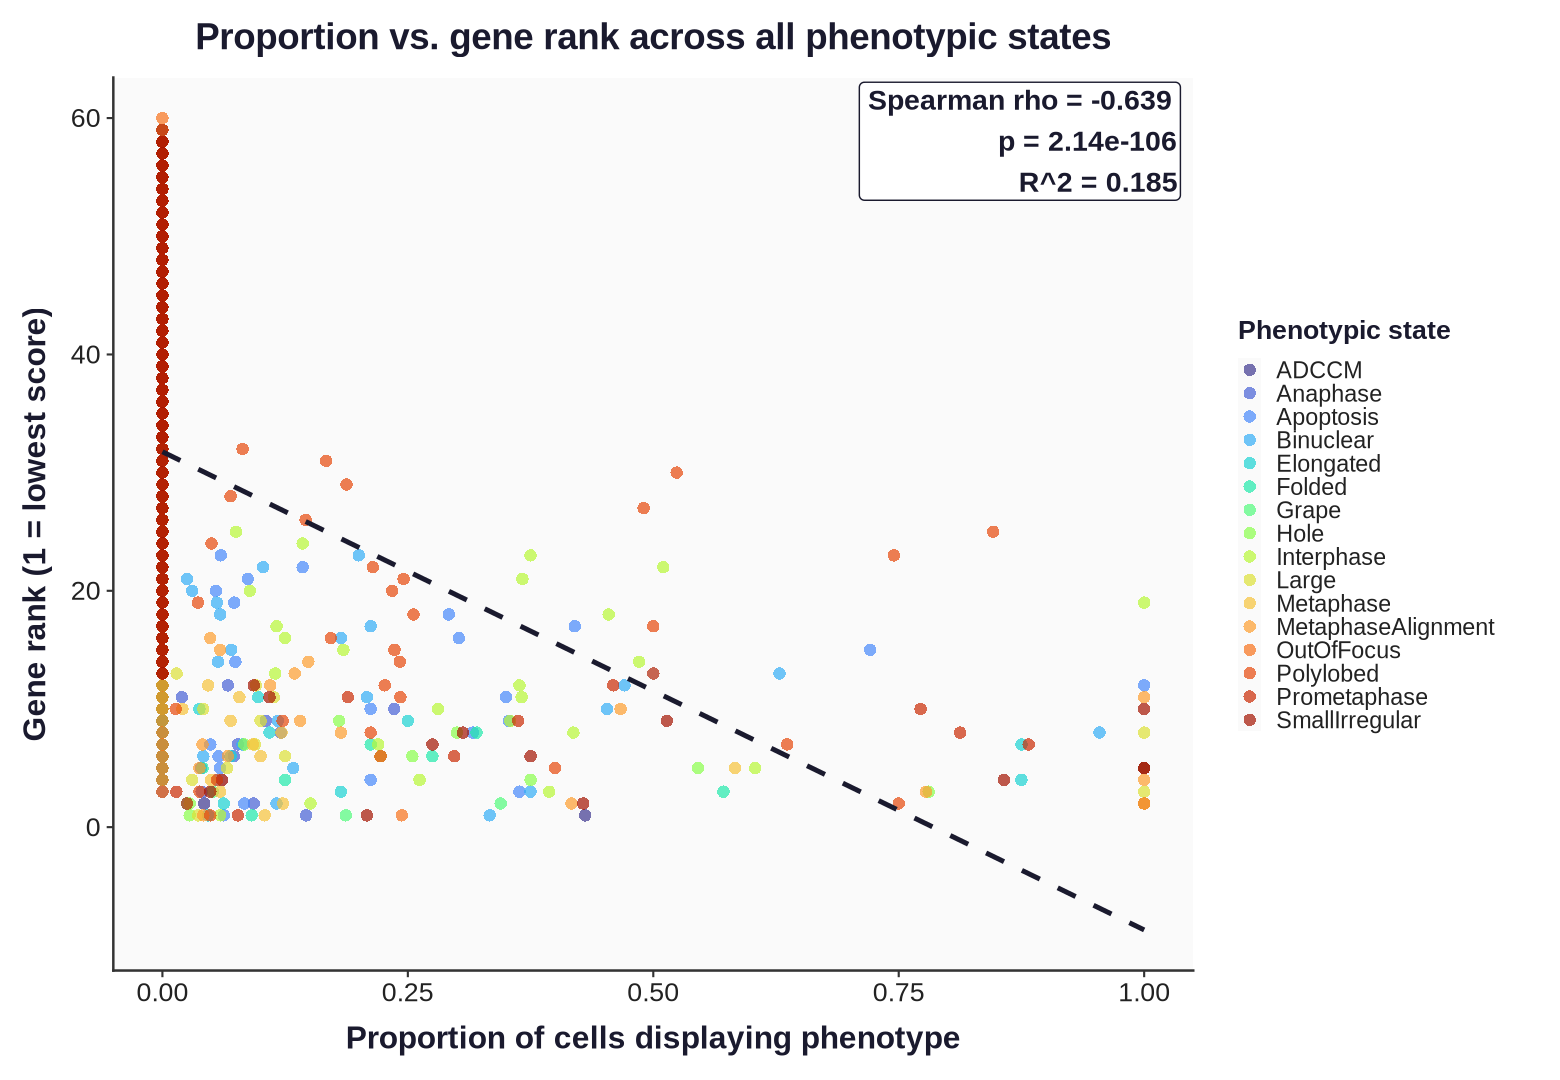

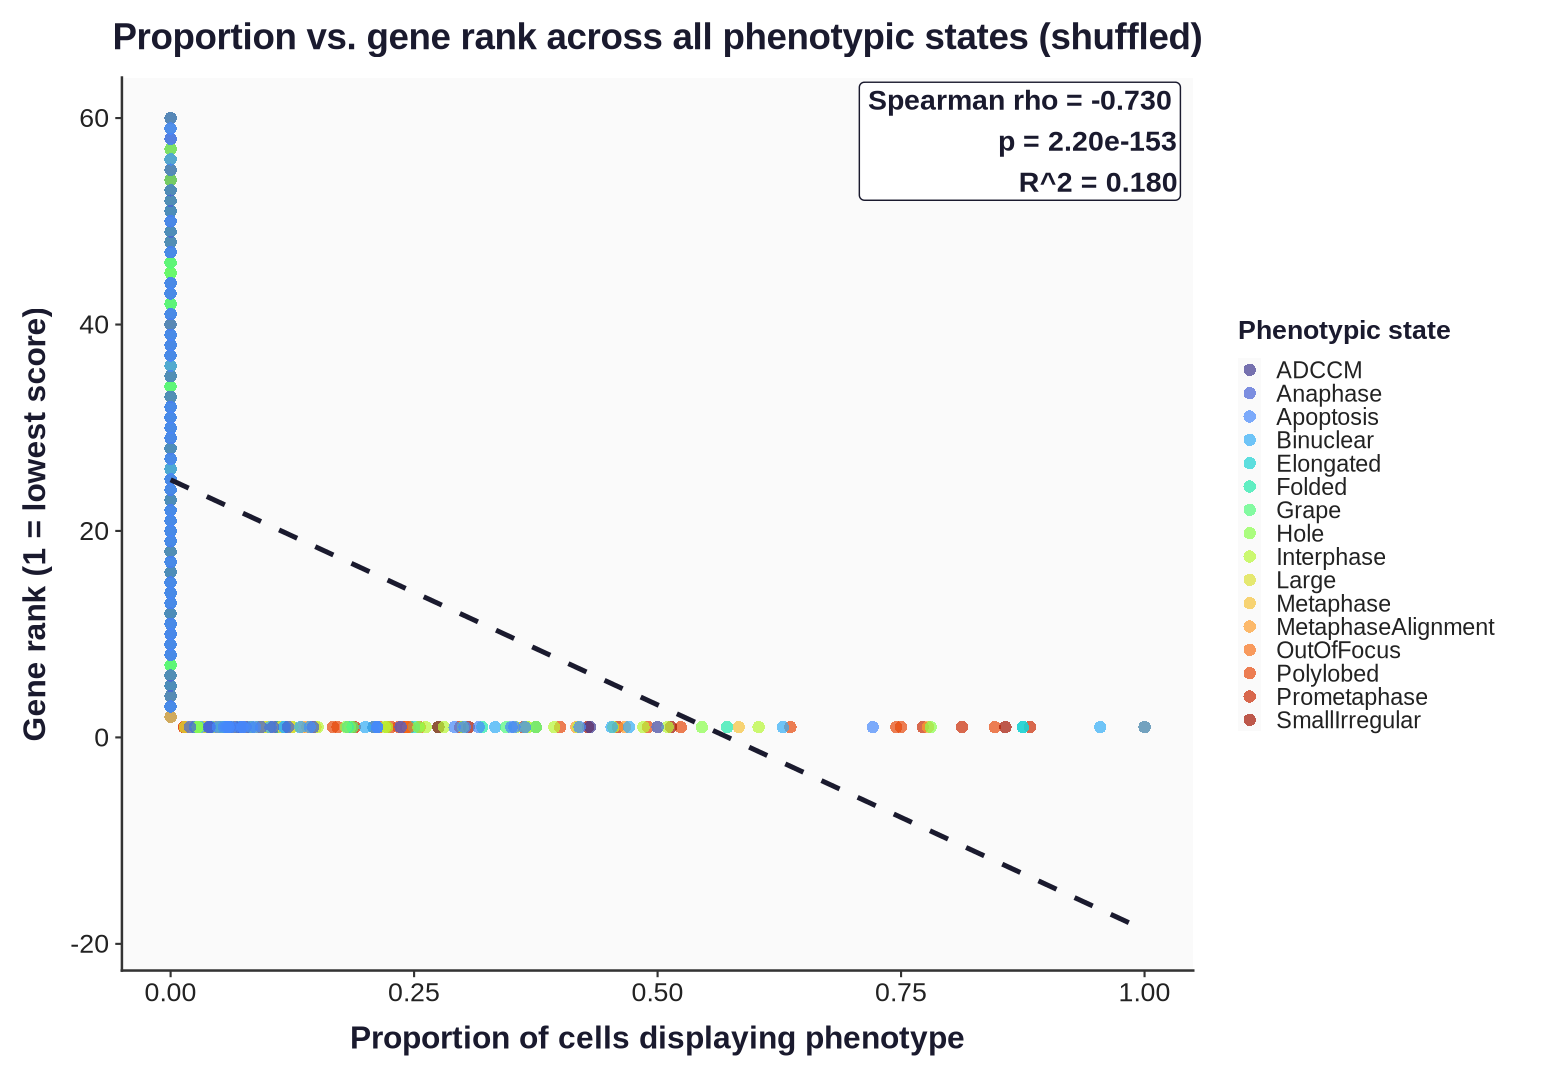

In [8]:
options(repr.plot.width = 13, repr.plot.height = 9)

plot_prop_vs_rank <- function(prop_df, title_txt, out_name) {
  fit <- lm(rank ~ proportion, data = prop_df)
  r_val <- suppressWarnings(cor(prop_df$proportion, prop_df$rank, use = 'complete.obs', method = 'pearson'))
  r2 <- r_val^2

  tst_all <- suppressWarnings(cor.test(prop_df$proportion, prop_df$rank, method = 'spearman', exact = FALSE))
  rho_all <- unname(tst_all$estimate)
  pval_all <- tst_all$p.value

  p_all <- ggplot(prop_df, aes(x = proportion, y = rank, color = ref_profile)) +
    geom_point(alpha = 0.7, size = 3.5, stroke = 0) +
    geom_smooth(
      method = 'lm', formula = y ~ x, se = FALSE,
      color = '#1a1a2e', linetype = 'dashed', linewidth = 1.4,
      inherit.aes = FALSE, aes(x = proportion, y = rank)
    ) +
    annotate(
      'label',
      x = Inf, y = Inf, hjust = 1.04, vjust = 1.04,
      label = sprintf('Spearman rho = %+.3f\np = %.2e\nR^2 = %.3f', rho_all, pval_all, r2),
      size = 6, label.size = 0.4, fill = 'white', color = '#1a1a2e', fontface = 'bold'
    ) +
    scale_color_viridis_d(option = 'turbo', begin = 0.05, end = 0.95) +
    labs(
      x = 'Proportion of cells displaying phenotype',
      y = 'Gene rank (1 = lowest score)',
      color = 'Phenotypic state',
      title = title_txt
    ) +
    theme_classic(base_size = 18) +
    theme(
      plot.title = element_text(face = 'bold', size = 22, color = '#1a1a2e', hjust = 0.5,
      margin = margin(b = 12)),
      axis.title.x = element_text(face = 'bold', size = 19, color = '#1a1a2e', margin = margin(t = 10)),
      axis.title.y = element_text(face = 'bold', size = 19, color = '#1a1a2e', margin = margin(r = 10)),
      axis.text.x = element_text(size = 16, color = '#222222'),
      axis.text.y = element_text(size = 16, color = '#222222'),
      axis.line = element_line(linewidth = 0.7, color = '#333333'),
      axis.ticks = element_line(linewidth = 0.6, color = '#333333'),
      axis.ticks.length = unit(4, 'pt'),
      legend.title = element_text(face = 'bold', size = 16, color = '#1a1a2e'),
      legend.text = element_text(size = 14, color = '#222222'),
      legend.key.size = unit(14, 'pt'),
      legend.position = 'right',
      legend.background = element_rect(fill = 'white', color = NA),
      panel.background = element_rect(fill = '#fafafa', color = NA),
      plot.background = element_rect(fill = 'white', color = NA),
      plot.margin = margin(14, 20, 14, 14)
    )

  out_path <- file.path(output_dir, out_name)
  ggsave(out_path, p_all, width = 13, height = 9, dpi = 300, bg = 'white')
  cat(sprintf('Saved -> %s\n', out_path))
  print(p_all)
}

plot_prop_vs_rank(
  prop_df,
  'Proportion vs. gene rank across all phenotypic states',
  'proportion_vs_rank_all_profiles.png'
)

plot_prop_vs_rank(
  shuf_prop_df,
  'Proportion vs. gene rank across all phenotypic states (shuffled)',
  'shuffled_proportion_vs_rank_all_profiles.png'
)